In [ ]:
# Write your code here.
import kagglehub
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils as vutils


In [18]:
path = kagglehub.dataset_download("balraj98/facades-dataset")

print("Path to dataset files:", path)


Path to dataset files: /root/.cache/kagglehub/datasets/balraj98/facades-dataset/versions/1


In [6]:
class PairedDataset(Dataset):
    def __init__(self, input_dir, gt_dir, transform=None, is_test=False):
        self.input_dir = input_dir
        self.gt_dir = gt_dir
        self.transform = transform
        self.is_test = is_test

        self.input_images = sorted([f for f in os.listdir(input_dir) if f.endswith('.jpg')])

    def __len__(self):
        return len(self.input_images)

    def __getitem__(self, idx):
        input_img_name = self.input_images[idx]

        if self.is_test:
            gt_img_name = input_img_name
        else:
            gt_img_name = input_img_name.replace('_B.jpg', '_A.jpg')

        # Construct full file paths
        input_path = os.path.join(self.input_dir, input_img_name)
        gt_path = os.path.join(self.gt_dir, gt_img_name)

        # Load images
        input_image = Image.open(input_path).convert('RGB')
        gt_image = Image.open(gt_path).convert('RGB')

        # Apply transformations if provided
        if self.transform:
            input_image = self.transform(input_image)
            gt_image = self.transform(gt_image)

        return input_image, gt_image

# Define transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

base_path = path
train_input_dir = os.path.join(base_path, 'trainB')
train_gt_dir = os.path.join(base_path, 'trainA')
test_input_dir = os.path.join(base_path, 'testB')
test_gt_dir = os.path.join(base_path, 'testA')

# Create dataset and loader
train_dataset = PairedDataset(
    input_dir=train_input_dir,
    gt_dir=train_gt_dir,
    transform=transform,
    is_test=False
)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

test_dataset = PairedDataset(
    input_dir=test_input_dir,
    gt_dir=test_gt_dir,
    transform=transform,
    is_test=True
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

for input_img, gt_img in train_loader:
    print(f"Training batch - Input shape: {input_img.shape}, GT shape: {gt_img.shape}")
    break

for input_img, gt_img in test_loader:
    print(f"Test batch - Input shape: {input_img.shape}, GT shape: {gt_img.shape}")
    break

Training batch - Input shape: torch.Size([1, 3, 256, 256]), GT shape: torch.Size([1, 3, 256, 256])
Test batch - Input shape: torch.Size([1, 3, 256, 256]), GT shape: torch.Size([1, 3, 256, 256])


In [7]:


# Generator U-Net
class UNetGenerator(nn.Module):
    def __init__(self):
        super(UNetGenerator, self).__init__()

        # Encoder
        self.enc1 = nn.Conv2d(3, 64, 4, stride=2, padding=1)
        self.enc2 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128))
        self.enc3 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256))
        self.enc4 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512))
        self.enc5 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512))
        self.enc6 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512))
        self.enc7 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512))
        self.enc8 = nn.Sequential(nn.LeakyReLU(0.2), nn.Conv2d(512, 512, 4, 2, 1))

        # Decoder
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.Dropout(0.5), nn.ReLU())
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(1024, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.Dropout(0.5), nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(1024, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.Dropout(0.5), nn.ReLU())
        self.dec4 = nn.Sequential(nn.ConvTranspose2d(1024, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU())
        self.dec5 = nn.Sequential(nn.ConvTranspose2d(1024, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.dec6 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.dec7 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU())
        self.final = nn.Sequential(nn.ConvTranspose2d(128, 3, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)
        e6 = self.enc6(e5)
        e7 = self.enc7(e6)
        e8 = self.enc8(e7)

        d1 = self.dec1(e8)
        d1 = torch.cat((d1, e7), dim=1)
        d2 = self.dec2(d1)
        d2 = torch.cat((d2, e6), dim=1)
        d3 = self.dec3(d2)
        d3 = torch.cat((d3, e5), dim=1)
        d4 = self.dec4(d3)
        d4 = torch.cat((d4, e4), dim=1)
        d5 = self.dec5(d4)
        d5 = torch.cat((d5, e3), dim=1)
        d6 = self.dec6(d5)
        d6 = torch.cat((d6, e2), dim=1)
        d7 = self.dec7(d6)
        d7 = torch.cat((d7, e1), dim=1)
        return self.final(d7)

# Discriminator: PatchGAN
class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, stride=2, padding=1),  # Input: 3 (label) + 3 (image)
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1, 4, stride=1, padding=1)  # Output: ~30x30 patch
        )

    def forward(self, x):
        return self.model(x)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = UNetGenerator().to(device)
discriminator = PatchGANDiscriminator().to(device)


In [9]:
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [11]:
criterion_GAN = nn.MSELoss()
criterion_L1 = nn.L1Loss()

num_epochs = 100
lambda_L1 = 100 # used in paper

In [12]:
real_label = torch.ones((1, 1, 30, 30)).to(device)
fake_label = torch.zeros((1, 1, 30, 30)).to(device)


In [13]:
for epoch in range(num_epochs):
    for i, (input_img, target_img) in enumerate(train_loader):
        input_img, target_img = input_img.to(device), target_img.to(device)

        #Train Discriminator -
        optimizer_D.zero_grad()

        # Real pair
        real_pair = torch.cat((input_img, target_img), dim=1)
        D_real = discriminator(real_pair)
        D_real_loss = criterion_GAN(D_real, real_label)

        # Fake pair
        generated_img = generator(input_img)
        fake_pair = torch.cat((input_img, generated_img.detach()), dim=1)
        D_fake = discriminator(fake_pair)
        D_fake_loss = criterion_GAN(D_fake, fake_label)

        D_loss = 0.5 * (D_real_loss + D_fake_loss)
        D_loss.backward()
        optimizer_D.step()

        #Train Generator -
        optimizer_G.zero_grad()

        # Adversarial loss
        fake_pair = torch.cat((input_img, generated_img), dim=1)
        D_fake = discriminator(fake_pair)
        G_adv_loss = criterion_GAN(D_fake, real_label)

        # L1 loss
        G_L1_loss = criterion_L1(generated_img, target_img)

        G_loss = G_adv_loss + lambda_L1 * G_L1_loss
        G_loss.backward()
        optimizer_G.step()
        if i % 50 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Batch [{i}/{len(train_loader)}] "
                  f"D_loss: {D_loss.item():.4f} G_loss: {G_loss.item():.4f}")

Epoch [0/100] Batch [0/400] D_loss: 0.7827 G_loss: 69.5833
Epoch [0/100] Batch [50/400] D_loss: 0.2722 G_loss: 45.0951
Epoch [0/100] Batch [100/400] D_loss: 0.1970 G_loss: 27.7064
Epoch [0/100] Batch [150/400] D_loss: 0.1968 G_loss: 36.3084
Epoch [0/100] Batch [200/400] D_loss: 0.0740 G_loss: 42.0541
Epoch [0/100] Batch [250/400] D_loss: 0.0484 G_loss: 47.2993
Epoch [0/100] Batch [300/400] D_loss: 0.0206 G_loss: 65.2799
Epoch [0/100] Batch [350/400] D_loss: 0.0288 G_loss: 37.0661
Epoch [1/100] Batch [0/400] D_loss: 0.0373 G_loss: 36.4790
Epoch [1/100] Batch [50/400] D_loss: 0.0580 G_loss: 31.4480
Epoch [1/100] Batch [100/400] D_loss: 0.1449 G_loss: 33.7876
Epoch [1/100] Batch [150/400] D_loss: 0.0570 G_loss: 32.2944
Epoch [1/100] Batch [200/400] D_loss: 0.0427 G_loss: 26.7547
Epoch [1/100] Batch [250/400] D_loss: 0.0565 G_loss: 39.4996
Epoch [1/100] Batch [300/400] D_loss: 0.0186 G_loss: 50.7564
Epoch [1/100] Batch [350/400] D_loss: 0.0210 G_loss: 31.8885
Epoch [2/100] Batch [0/400] D_

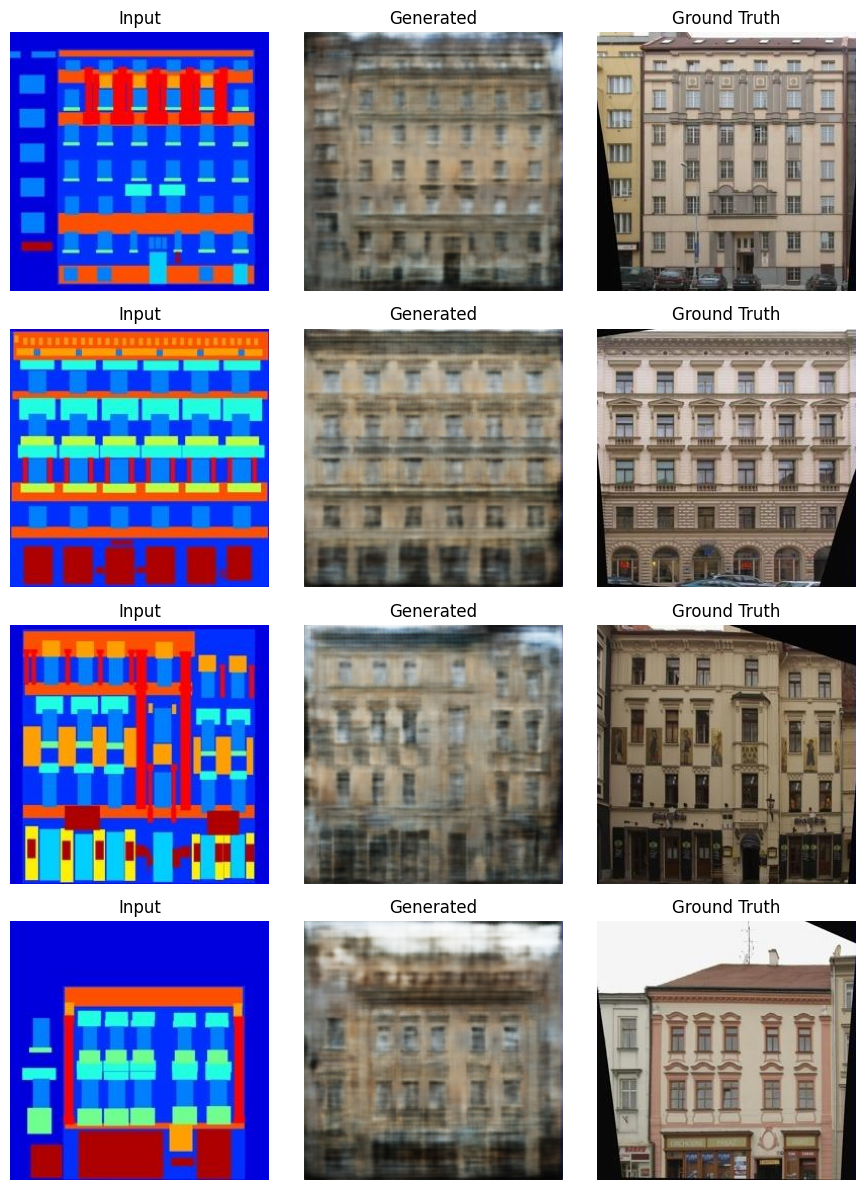

In [17]:


def denormalize(tensor):
    return tensor * 0.5 + 0.5  # Convert from [-1,1] to [0,1]

generator.eval()

fig, axes = plt.subplots(4, 3, figsize=(9, 12))  #4 rows, 3 cols

with torch.no_grad():
    for i, (input_img, target_img) in enumerate(test_loader):
        if i >= 4:
            break

        input_img = input_img.to(device)
        generated_img = generator(input_img)
        input_img = denormalize(input_img.cpu().squeeze(0))
        generated_img = denormalize(generated_img.cpu().squeeze(0))
        target_img = denormalize(target_img.cpu().squeeze(0))

        input_np = input_img.permute(1, 2, 0).numpy()
        generated_np = generated_img.permute(1, 2, 0).numpy()
        target_np = target_img.permute(1, 2, 0).numpy()

        axes[i, 0].imshow(input_np)
        axes[i, 0].set_title("Input")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(generated_np)
        axes[i, 1].set_title("Generated")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(target_np)
        axes[i, 2].set_title("Ground Truth")
        axes[i, 2].axis("off")

plt.tight_layout()
plt.show()
